In [1]:
import os
import sys
import wandb
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))

In [2]:
from model import GraphSAGENet
from process_data import DataProcessor
from train import train_epoch_full_graph, evaluate_full_graph

In [3]:
# Initialize wandb
run = wandb.init(
    entity="abdelrahman-helal-minerva-university",
    project="graphsage-more_neighbors",
    config={
        "model": "GraphSAGE",
        "num_layers": 2,
        "hidden_channels": 64,
        "mlp_hidden": 128,
        "learning_rate": 0.01,
        "num_epochs": 100,
        "device": "cpu" if not torch.cuda.is_available() else "cuda"
    },
    mode="online"  # Use online mode to avoid local file issues
)

wandb: Currently logged in as: abdelrahman-helal (abdelrahman-helal-minerva-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
data_path = 'D:\Minerva/Senior Year/Capstone/DM_FIREbox_fresh/data/firebox_data/FIREbox_z=0.txt'
data_processor = DataProcessor(file_path=data_path)
preliminary_data = data_processor.load_data()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_8600\3081214222.py:1: SyntaxWarning: invalid escape sequence '\M'
  data_path = 'D:\Minerva/Senior Year/Capstone/DM_FIREbox_fresh/data/firebox_data/FIREbox_z=0.txt'


In [5]:
data_processor.create_graph_data(k=20, include_lg_Mstar=True, stratify_bins=10)
data = data_processor.data

In [6]:
print(f'Log Halo Mass Range in training set: {min(data.y[data.train_mask])} to {max(data.y[data.train_mask])}')
print(f'Log Halo Mass Range in test set: {min(data.y[data.test_mask])} to {max(data.y[data.test_mask])}')
print(f'Mean Log halo mass in training set: {data.y[data.train_mask].mean():.4f}')
print(f'Mean Log halo mass in test set: {data.y[data.test_mask].mean():.4f}')


Log Halo Mass Range in training set: tensor([7.1255]) to tensor([13.0780])
Log Halo Mass Range in test set: tensor([7.3567]) to tensor([12.5080])
Mean Log halo mass in training set: 9.2808
Mean Log halo mass in test set: 9.2770


In [9]:
# Training configuration
num_layers = 2
hidden_channels = 64
mlp_hidden = 128
learning_rate = 0.01
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")
print(f"Data: {data}")
print(f"Train nodes: {data.train_mask.sum()}")
print(f"Test nodes: {data.test_mask.sum()}")

# for evaluation: sample *all* neighbors (exhaustive) so predictions are stable
val_loader = NeighborLoader(
    data,
    num_neighbors=[-1] * num_layers,   # -1 => take all neighbors at that hop
    input_nodes=data.test_mask,
    batch_size=eval_batch_size,
    shuffle=False,
)

Using device: cpu


NameError: name 'data' is not defined

In [7]:
num_layers = 2
hidden_channels = 64
mlp_hidden = 128
learning_rate = 0.001
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")
print(f"Data: {data}")
print(f"Train nodes: {data.train_mask.sum()}")
print(f"Test nodes: {data.test_mask.sum()}")

# Initialize model
model = GraphSAGENet(
    in_channels=data.x.size(1),
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    mlp_hidden=mlp_hidden
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Model: {model}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")


Using device: cpu
Data: Data(x=[6213, 8], edge_index=[2, 248520], y=[6213, 1], pos=[6213, 3], train_mask=[6213], test_mask=[6213])
Train nodes: 4970
Test nodes: 1243
Model: GraphSAGENet(
  (convs): ModuleList(
    (0): SAGEConv(8, 64, aggr=mean)
    (1): SAGEConv(64, 64, aggr=mean)
  )
  (norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (mlp): MLPRegressor(
    (mlp): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)
Number of parameters: 18049


In [17]:
# Training loop
best_val_rmse = float('inf')
train_losses = []
val_rmses = []
val_maes = []

for epoch in range(num_epochs):
    # Training
    train_loss = train_epoch_full_graph(model, optimizer, data, device)
    train_losses.append(train_loss)
    
    # Evaluation
    val_rmse, val_mae, _, _ = evaluate_full_graph(model, data, device)
    val_rmses.append(val_rmse)
    val_maes.append(val_mae)
    # Log metrics to wandb
    run.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "learning_rate": optimizer.param_groups[0]['lr']
    })
    
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        # Save best model
        torch.save(model.state_dict(), "../logs/best_model.pt")
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE: {best_val_rmse:.4f}')

# Finish wandb run
run.finish()


Epoch 000, Train Loss: 1.2902, Val RMSE: 0.7031, Val MAE: 0.5257
Epoch 010, Train Loss: 1.1751, Val RMSE: 0.6389, Val MAE: 0.4834
Epoch 020, Train Loss: 1.0951, Val RMSE: 0.6200, Val MAE: 0.4703
Epoch 030, Train Loss: 1.0767, Val RMSE: 0.5647, Val MAE: 0.4207
Epoch 040, Train Loss: 0.9786, Val RMSE: 0.5216, Val MAE: 0.3869
Epoch 050, Train Loss: 0.9040, Val RMSE: 0.4791, Val MAE: 0.3492
Epoch 060, Train Loss: 0.8447, Val RMSE: 0.4273, Val MAE: 0.3098
Epoch 070, Train Loss: 0.7986, Val RMSE: 0.3853, Val MAE: 0.2775
Epoch 080, Train Loss: 0.7694, Val RMSE: 0.3554, Val MAE: 0.2530
Epoch 090, Train Loss: 0.7258, Val RMSE: 0.3313, Val MAE: 0.2381


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Best validation RMSE: 0.3191


epoch,▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▂▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▅█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae,██▇▆▆▃▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_rmse,███▇▆▆▅▃▃▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,99
learning_rate,0.001
train_loss,0.71565
val_mae,0.23002
val_rmse,0.31906


Getting predictions for the entire dataset...


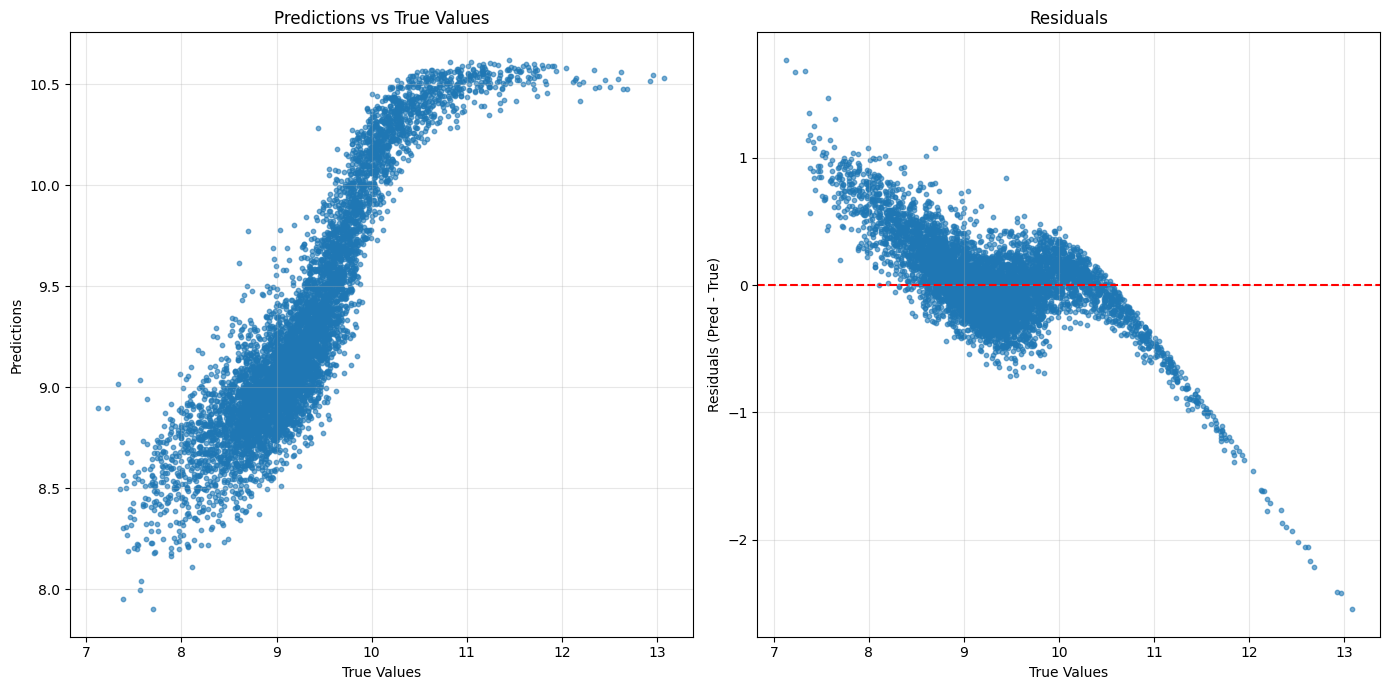

In [20]:
print("Getting predictions for the entire dataset...")
all_predictions = model.predict(data, device)
all_true_values = data.y.view(-1).cpu()
residuals = all_predictions - all_true_values

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].scatter(all_true_values, all_predictions, alpha=0.6, s=10)
ax[0].set_xlabel('True Values')
ax[0].set_ylabel('Predictions')
ax[0].set_title('Predictions vs True Values')
ax[0].grid(True, alpha=0.3)

ax[1].scatter(all_true_values, residuals, alpha=0.6, s=10)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('True Values')
ax[1].set_ylabel('Residuals (Pred - True)')
ax[1].set_title('Residuals')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
k_values = [4, 8, 12, 16, 20, 24, 28]
all_k_predictions = []
all_k_residuals = []
train_losses = []
val_rmses = []
val_maes = []

for k in k_values:
    data_processor.create_graph_data(k=k, include_lg_Mstar=True, stratify_bins=10)
    data = data_processor.data
    model = GraphSAGENet(
        in_channels=data.x.size(1),
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        mlp_hidden=mlp_hidden
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_rmse = float('inf')
    train_loss = []
    val_rmse = []
    val_mae = []
    
    for epoch in range(num_epochs):
        train_loss.append(train_epoch_full_graph(model, optimizer, data, device))
        val_rmse.append(evaluate_full_graph(model, data, device)[0])
        val_mae.append(evaluate_full_graph(model, data, device)[1])
    
    train_losses.append(train_loss[-1])
    val_rmses.append(val_rmse[-1])
    val_maes.append(val_mae[-1])
    predictions = model.predict(data, device)
    residuals = predictions - data.y.view(-1).cpu()
    all_k_predictions.append(predictions)
    all_k_residuals.append(residuals)

    if val_rmse[-1] < best_val_rmse:
        best_val_rmse = val_rmse[-1]
    
    print(f'Best validation RMSE for k={k}: {best_val_rmse:.4f}')

Best validation RMSE for k=4: 0.5445
Best validation RMSE for k=8: 0.5226
Best validation RMSE for k=12: 0.6157
Best validation RMSE for k=16: 0.5933
Best validation RMSE for k=20: 0.6133
Best validation RMSE for k=24: 0.6064
Best validation RMSE for k=28: 0.5935


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create visualization for each k value
fig, axes = plt.subplots(7, 2, figsize=(14, 28))

# Assuming you have 7 different k values
k_values = range(1, 8)  # Adjust this based on your actual k values

for i, k in enumerate(k_values):
    # Get predictions and residuals for this k value
    predictions = all_k_predictions[i]  # Adjust indexing based on your data structure
    residuals = all_k_residuals[i]
    true_values = all_true_values
    
    # True vs Predictions plot
    axes[i, 0].scatter(true_values, predictions, alpha=0.6, s=10)
    axes[i, 0].set_xlabel('True Values')
    axes[i, 0].set_ylabel('Predictions')
    axes[i, 0].set_title(f'k={k}: Predictions vs True Values')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Add perfect prediction line
    min_val = min(true_values.min(), predictions.min())
    max_val = max(true_values.max(), predictions.max())
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    
    # Residuals plot
    axes[i, 1].scatter(true_values, residuals, alpha=0.6, s=10)
    axes[i, 1].axhline(y=0, color='r', linestyle='--')
    axes[i, 1].set_xlabel('True Values')
    axes[i, 1].set_ylabel('Residuals (Pred - True)')
    axes[i, 1].set_title(f'k={k}: Residuals')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
